### Import libraries

In [121]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

### Load the dataset


In [122]:
df = pd.read_csv("Ecommerce Customers.csv")

In [123]:
df.head(2)

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933


### Understand the dataset

In [124]:
df.shape

(500, 8)

In [125]:
df.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


In [126]:
df.duplicated().sum()

np.int64(0)

In [127]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    str    
 1   Address               500 non-null    str    
 2   Avatar                500 non-null    str    
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), str(3)
memory usage: 31.4 KB


In [128]:
df.isnull().sum()

Email                   0
Address                 0
Avatar                  0
Avg. Session Length     0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
dtype: int64

### Remove unnecessary columns

In [129]:
df = df.drop(columns=["Email", "Address", "Avatar"])

### Define X and y

In [130]:
y = df["Yearly Amount Spent"]
X = df.drop(columns=["Yearly Amount Spent"])

### Exploratory Data Analysis

In [131]:
X.head(3)

,Avg. Session Length,Time on App,Time on Website,Length of Membership
0,34.497268,12.655651,39.577668,4.082621
1,31.926272,11.109461,37.268959,2.664034
2,33.000915,11.330278,37.110597,4.104543


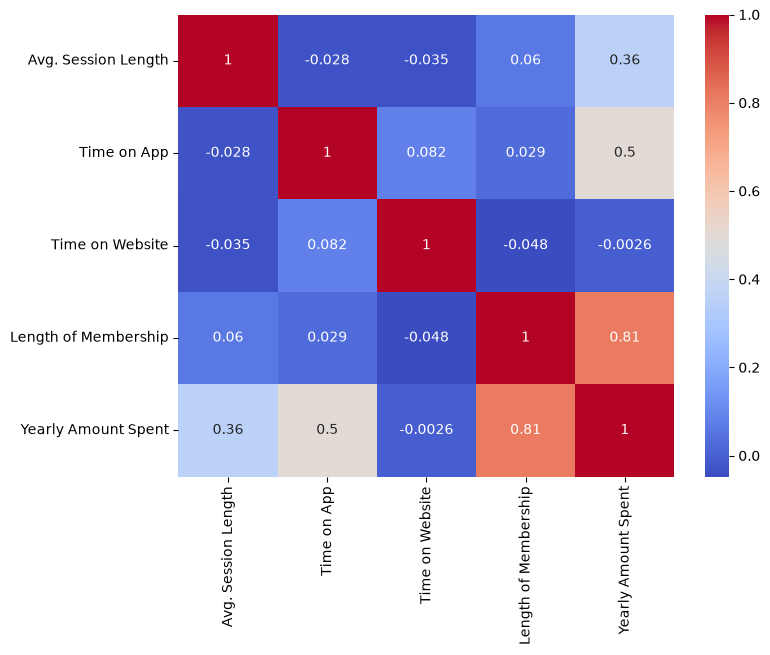

In [132]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

### Visualize the target

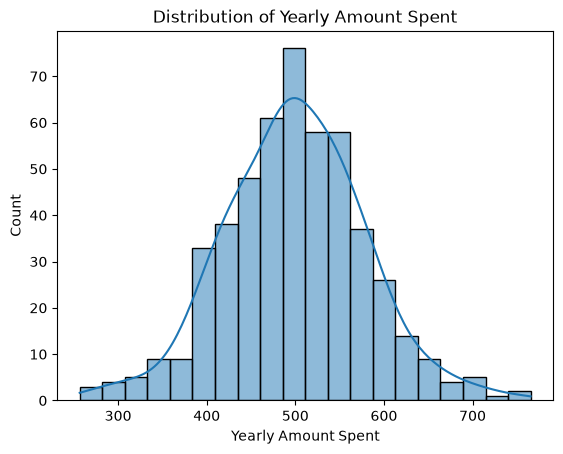

In [133]:
sns.histplot(df["Yearly Amount Spent"], kde=True)

plt.title("Distribution of Yearly Amount Spent")
plt.show()

### Look at individual relationships

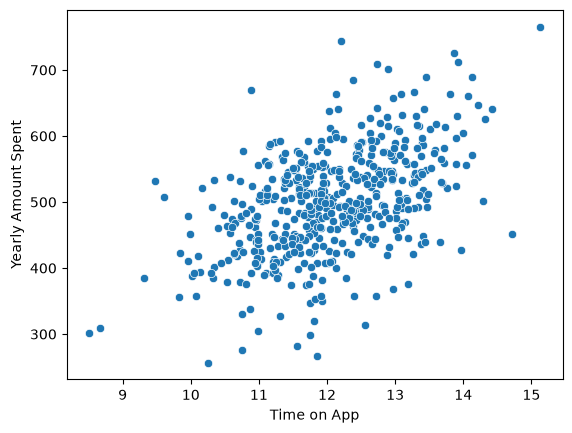

In [134]:
sns.scatterplot(
    data=df,
    x="Time on App",
    y="Yearly Amount Spent"
)

plt.show()

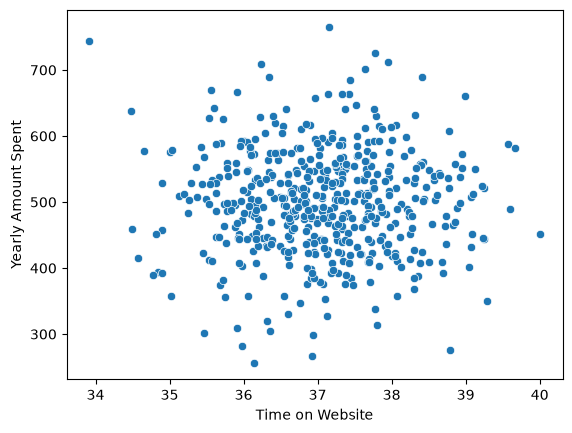

In [135]:
sns.scatterplot(
    data=df,
    x="Time on Website",
    y="Yearly Amount Spent"
)

plt.show()

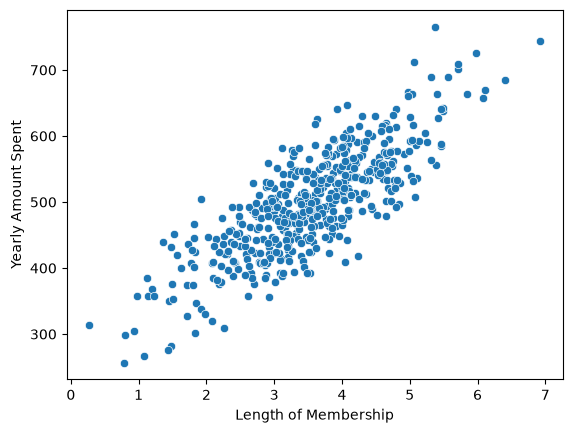

In [136]:
sns.scatterplot(
    data=df,
    x="Length of Membership",
    y="Yearly Amount Spent"
)

plt.show()

### Split the data


In [137]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=7
)

### Train Linear Regression

In [138]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

### Make predictions

In [139]:
y_pred = model.predict(X_test)

In [140]:
print(y_pred[:10])

[615.72759986 560.78188902 546.88770728 577.3291127  587.75332759
 501.5727112  518.8074817  532.97813734 589.79144092 454.90012192]


### Evaluate the model

In [141]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", rmse)
print("MAE:", mae)
print("R²:", r2)

RMSE: 10.485766250121788
MAE: 8.170120725569873
R²: 0.982120304154978


### Examine the coefficients

In [142]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coefficients)


                Feature  Coefficient
0   Avg. Session Length    25.399178
1           Time on App    38.388200
2       Time on Website     0.794018
3  Length of Membership    61.811961


### Find the most important variable

In [143]:
coefficients["Absolute Coefficient"] = (
    coefficients["Coefficient"].abs()
)

coefficients.sort_values(
    "Absolute Coefficient",
    ascending=False
)

,Feature,Coefficient,Absolute Coefficient
3,Length of Membership,61.811961,61.811961
1,Time on App,38.388200,38.388200
0,Avg. Session Length,25.399178,25.399178
2,Time on Website,0.794018,0.794018


### Plot actual vs predicted

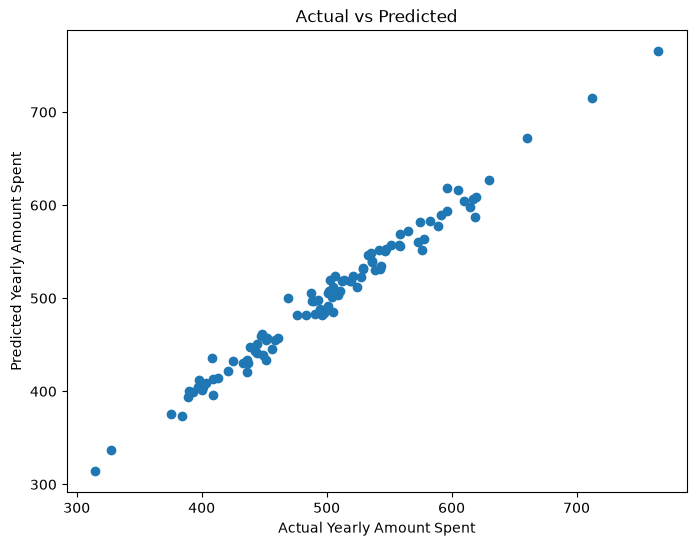

In [144]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Yearly Amount Spent")
plt.ylabel("Predicted Yearly Amount Spent")

plt.title("Actual vs Predicted")

plt.show()


### Check residuals

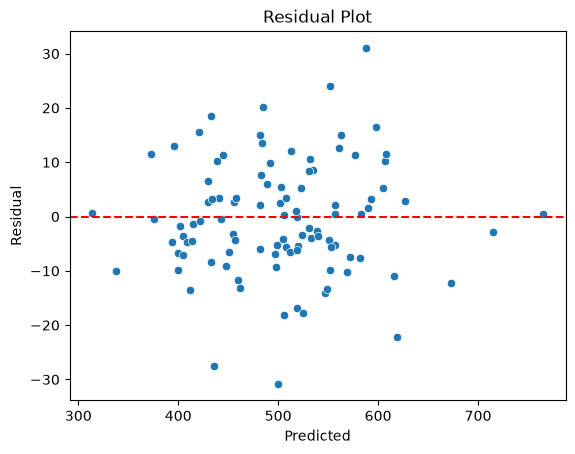

In [145]:
residuals = y_test - y_pred

sns.scatterplot(
    x=y_pred,
    y=residuals
)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()


### Try other models

Random Forest Regressor


In [146]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [147]:
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2:", r2_score(y_test, rf_pred))

MAE: 14.542380823502599
RMSE: 20.155138287622933
R2: 0.9339410985908034


Use cross-validation

In [148]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    LinearRegression(),
    X,
    y,
    cv=5,
    scoring="r2"
)

print(scores)
print("Average R²:", scores.mean())


[0.98274654 0.9821047  0.98717189 0.9842572  0.98219012]
Average R²: 0.9836940897539079


## we are going to build our own multiple linear regression model

In [149]:
class MyMultiLinear:

    def __init__(self):
        self.coef_ = None
        self.intercept = None

    def fit(self,X_train,y_train):
        X_train = np.insert(X_train,0,1,axis=1)

        # cal coef
        betas = np.linalg.inv(np.dot(X_train.T, X_train)).dot(X_train.T).dot(y_train)
        # print(betas)
        self.coef_ = betas[1:]
        self.intercept = betas[0]

    def predict(self, X_test):
        # pass
        y_pred = self.intercept + np.dot(X_test,self.coef_)
        return y_pred

In [150]:
lr = MyMultiLinear()
lr.fit(X_train,y_train)

In [151]:
X_train.shape

(400, 4)

In [152]:
y_pred = lr.predict(X_test)
print(y_pred)

[615.72759986 560.78188902 546.88770728 577.3291127  587.75332759
 501.5727112  518.8074817  532.97813734 589.79144092 454.90012192
 456.87437912 534.60331614 399.67257715 505.24865684 556.94076454
 550.96828762 488.62820027 500.16762151 507.60704971 551.74192476
 482.1260595  455.65124057 531.7879859  399.86871569 715.19098519
 530.52250409 506.28258669 606.5629379  438.78356852 404.66126884
 435.7755854  503.26856849 443.13120058 569.13905049 482.94429319
 421.01387437 531.22690222 538.84957777 497.54819586 396.1068709
 507.45807368 408.39826601 618.55428958 522.54744369 557.2230412
 414.66338655 519.50906127 411.75793375 457.71088365 498.46822175
 404.56496261 337.43308341 481.72722854 672.62334227 553.26403659
 447.44828915 450.42358037 401.7584363  512.56477243 540.06686012
 445.10400245 518.28022766 572.2780651  393.61387239 765.06045994
 375.91600765 582.60587625 548.75340527 441.19823133 433.03405547
 430.11561853 484.08640688 433.36931526 582.29013552 459.37174593
 627.2829036

In [119]:
X_test.shape

(100, 4)

In [153]:
r2_score(y_test,y_pred)

0.9821203041549317